# Final Forecast

This notebook runs the final selected model on the groundwater time series project. It focuses on one model only : a linear autoregressive model using the last 18 months, the month of the year (one-hot encoding), and summary statistics (average of the last 3, 6 and 12 month and the standard deviation of the last 12 month).


## Why This Model?

This model was kept because it gave the best performance while staying simple, stable, and easy to explain on a relatively small monthly dataset. Other, more complex models were considered not ideal on the small set of data at our disposal.


In [1]:
import os
import warnings

os.environ.setdefault('MPLCONFIGDIR', '/tmp/mpl')
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [2]:
INPUT_LENGTH = 18
VALID_MONTHS = 48


def load_monthly_series(csv_path):
    df = pd.read_csv(csv_path, sep=';', parse_dates=['date'], index_col='date')
    return df.interpolate(method='time').resample('ME').mean()['target']


def month_one_hot(date):
    values = [0.0] * 12
    values[date.month - 1] = 1.0
    return values


def make_features(history, next_date, input_length=INPUT_LENGTH):
    values = np.asarray(history, dtype=float)
    features = values[-input_length:].tolist()
    features += month_one_hot(next_date)
    features += [
        values[-3:].mean(),
        values[-6:].mean(),
        values[-12:].mean(),
        values[-12:].std(),
    ]
    return np.asarray(features, dtype=float)


def build_training_data(series, input_length=INPUT_LENGTH):
    xs = []
    ys = []
    for i in range(input_length, len(series)):
        history = series.iloc[i - input_length:i].values
        xs.append(make_features(history, series.index[i], input_length))
        ys.append(series.iloc[i])
    return np.asarray(xs), np.asarray(ys)


def recursive_forecast(model, history, future_index, input_length=INPUT_LENGTH):
    values = list(history.values)
    predictions = []
    for date in future_index:
        x = make_features(values, date, input_length).reshape(1, -1)
        pred = float(model.predict(x)[0])
        predictions.append(pred)
        values.append(pred)
    return np.asarray(predictions)


In [3]:
raw_daily = pd.read_csv('train.csv', sep=';', parse_dates=['date'])
monthly_series = load_monthly_series('train.csv')
test_dates = pd.read_csv('test.csv', sep=';', parse_dates=['date'])['date']

train_series = monthly_series.iloc[:-VALID_MONTHS]
valid_series = monthly_series.iloc[-VALID_MONTHS:]

print('Daily rows:', len(raw_daily))
print('Monthly observations:', len(monthly_series))
print('Train months:', len(train_series))
print('Validation months:', len(valid_series))
print('Validation period:', valid_series.index.min().date(), 'to', valid_series.index.max().date())


Daily rows: 8766
Monthly observations: 288
Train months: 240
Validation months: 48
Validation period: 2015-01-31 to 2018-12-31


## Data Overview

The first figure shows the raw daily sensor values. The second figure shows the monthly series used by the model.


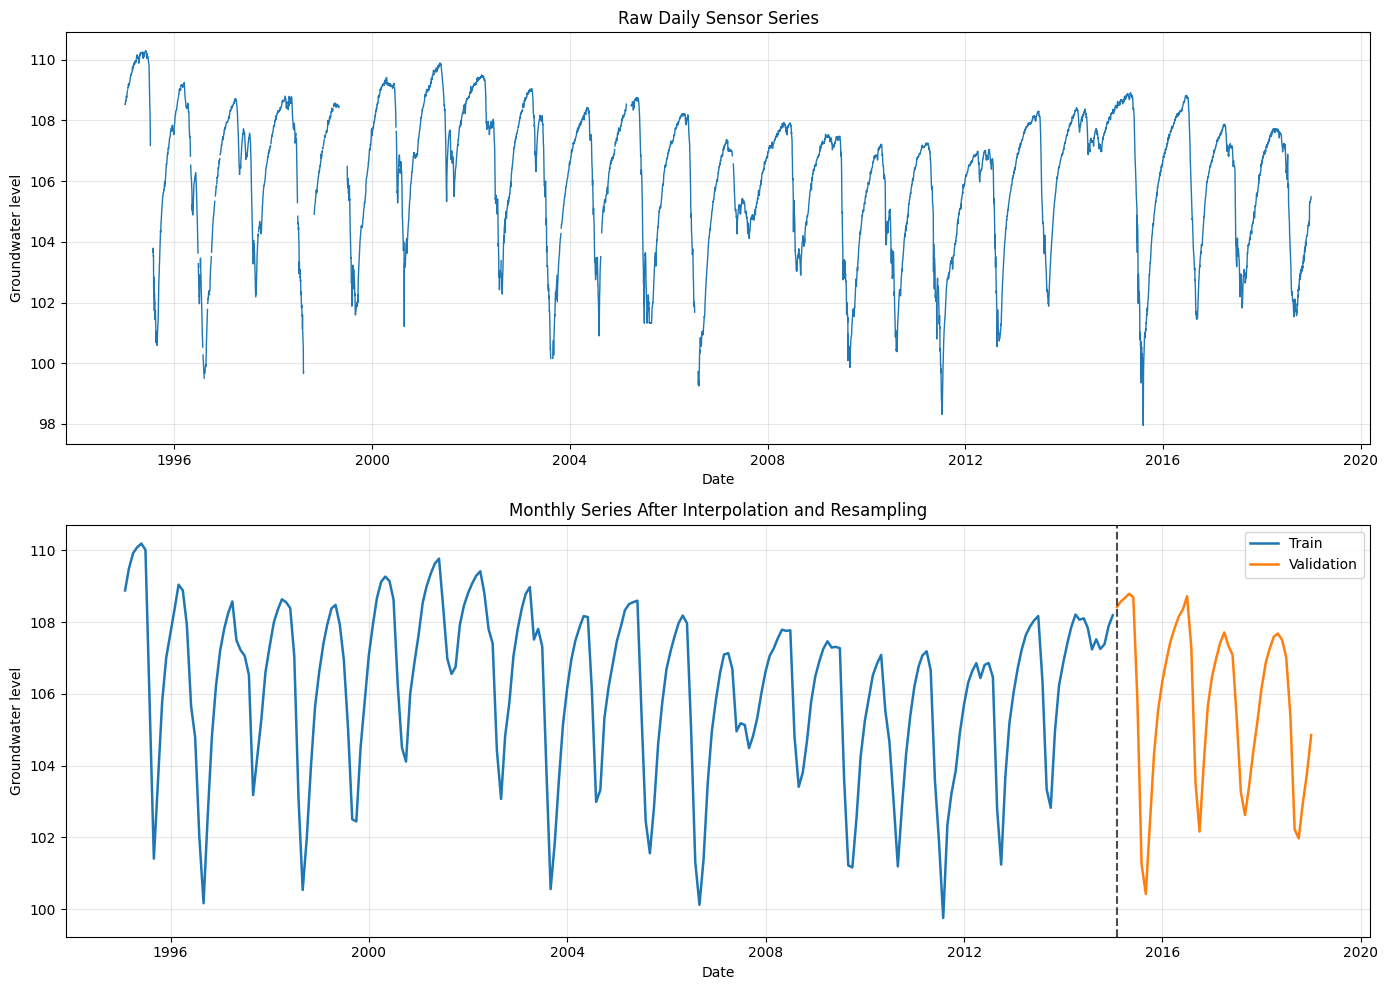

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

axes[0].plot(raw_daily['date'], raw_daily['target'], color='tab:blue', linewidth=1.0)
axes[0].set_title('Raw Daily Sensor Series')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Groundwater level')
axes[0].grid(alpha=0.3)

axes[1].plot(train_series.index, train_series.values, color='tab:blue', label='Train', linewidth=1.8)
axes[1].plot(valid_series.index, valid_series.values, color='tab:orange', label='Validation', linewidth=1.8)
axes[1].axvline(valid_series.index[0], color='black', linestyle='--', alpha=0.7)
axes[1].set_title('Monthly Series After Interpolation and Resampling')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Groundwater level')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [5]:
X_train, y_train = build_training_data(train_series)
model = LinearRegression()
model.fit(X_train, y_train)

valid_predictions = recursive_forecast(model, train_series, valid_series.index)
residuals = valid_series.values - valid_predictions

metrics_df = pd.DataFrame(
    {
        'metric': ['MAE', 'RMSE_3M', 'RMSE_6M', 'RMSE_12M', 'RMSE_48M'],
        'value': [
            mean_absolute_error(valid_series.values, valid_predictions),
            mean_squared_error(valid_series.values[:3], valid_predictions[:3]) ** 0.5,
            mean_squared_error(valid_series.values[:6], valid_predictions[:6]) ** 0.5,
            mean_squared_error(valid_series.values[:12], valid_predictions[:12]) ** 0.5,
            mean_squared_error(valid_series.values, valid_predictions) ** 0.5,
        ],
    }
)

metrics_df


,metric,value
0,MAE,0.717685
1,RMSE_3M,0.124231
2,RMSE_6M,0.606102
3,RMSE_12M,1.384167
4,RMSE_48M,1.088534


## Validation Forecast

The first plot shows the full validation block against the forecast. The second plot zooms into the first 12 months, which is useful because the assignment cares about short and medium forecast horizons.


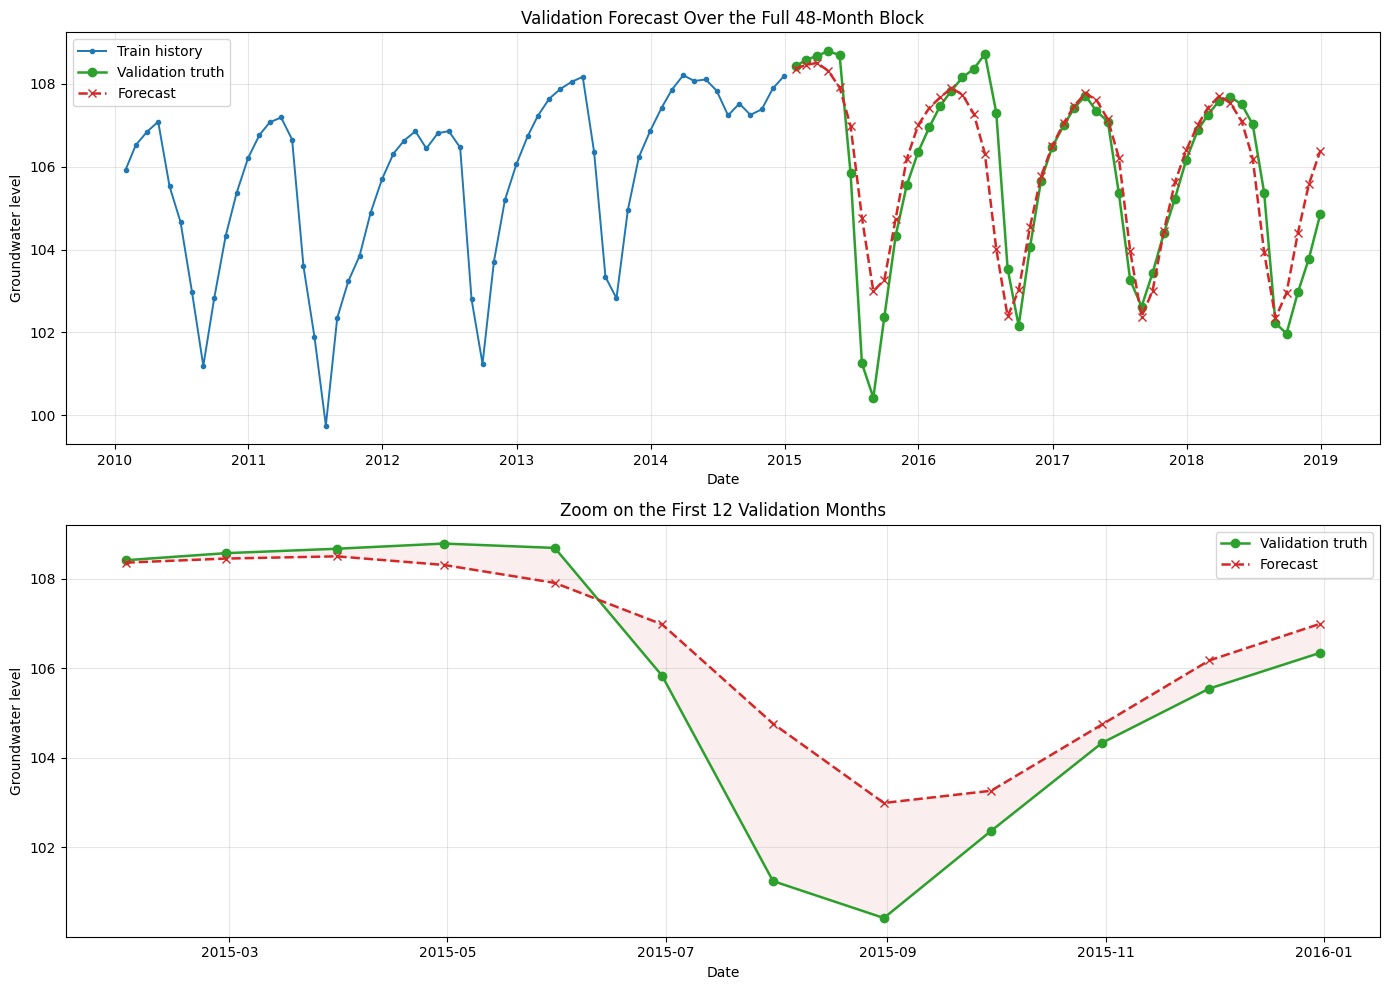

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

history = train_series.iloc[-60:]
axes[0].plot(history.index, history.values, label='Train history', color='tab:blue', marker='.', linewidth=1.4)
axes[0].plot(valid_series.index, valid_series.values, label='Validation truth', color='tab:green', marker='o', linewidth=1.8)
axes[0].plot(valid_series.index, valid_predictions, label='Forecast', color='tab:red', linestyle='--', marker='x', linewidth=1.8)
axes[0].set_title('Validation Forecast Over the Full 48-Month Block')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Groundwater level')
axes[0].legend()
axes[0].grid(alpha=0.3)

zoom_idx = valid_series.index[:12]
axes[1].plot(zoom_idx, valid_series.values[:12], label='Validation truth', color='tab:green', marker='o', linewidth=1.8)
axes[1].plot(zoom_idx, valid_predictions[:12], label='Forecast', color='tab:red', linestyle='--', marker='x', linewidth=1.8)
axes[1].fill_between(zoom_idx, valid_series.values[:12], valid_predictions[:12], color='tab:red', alpha=0.08)
axes[1].set_title('Zoom on the First 12 Validation Months')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Groundwater level')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Final Forecast Export

After validation, the model is retrained on the full monthly history and used to forecast the dates contained in `test.csv`.


In [8]:
full_X, full_y = build_training_data(monthly_series)
final_model = LinearRegression()
final_model.fit(full_X, full_y)

final_predictions = recursive_forecast(final_model, monthly_series, pd.DatetimeIndex(test_dates))
final_forecast_df = pd.DataFrame({'date': test_dates, 'target': final_predictions})
final_forecast_df.to_csv('final_forecast_predictions.csv', sep=';', index=False, float_format='%.4f')

final_forecast_df.head(12)


,date,target
0,2019-01-01,105.960767
1,2019-02-01,106.681640
2,2019-03-01,107.150950
3,2019-04-01,107.107505
4,2019-05-01,106.649627
5,2019-06-01,105.692600
6,2019-07-01,103.286039
7,2019-08-01,101.553845
8,2019-09-01,102.311863
9,2019-10-01,103.884205


## Conclusion

The final selected model is a linear autoregressive regression using the last 18 months, the month of the year, and rolling summary statistics.

### Results on Validation

- RMSE over the full 48-month validation block: about **1.09**
- RMSE over the first 12 months: about **1.38**
- RMSE over the first 6 months: about **0.61**
- RMSE over the first 3 months: about **0.12**

### Why This Model Was Chosen

This model was kept because it gave the best performance while staying simple and stable on a relatively small monthly dataset. Other, more complex models were considered not ideal on the small set of data at our disposal.

- It performed best on the chosen metric (RMSE).
- It stayed stable over a long 48-month period.
- Furthermore, it is simpler than other models while staying very performant overall.
- Its simplicity matches the one of the dataset : smooth, seasonal and periodic.

This project shows that the best forecasting model was in fact the simplest one, according to the results we got. On this dataset, a basic linear autoregressive model generalized better than the more sophisticated alternatives, which makes it the safest final choice for both performance and extrapolation.
